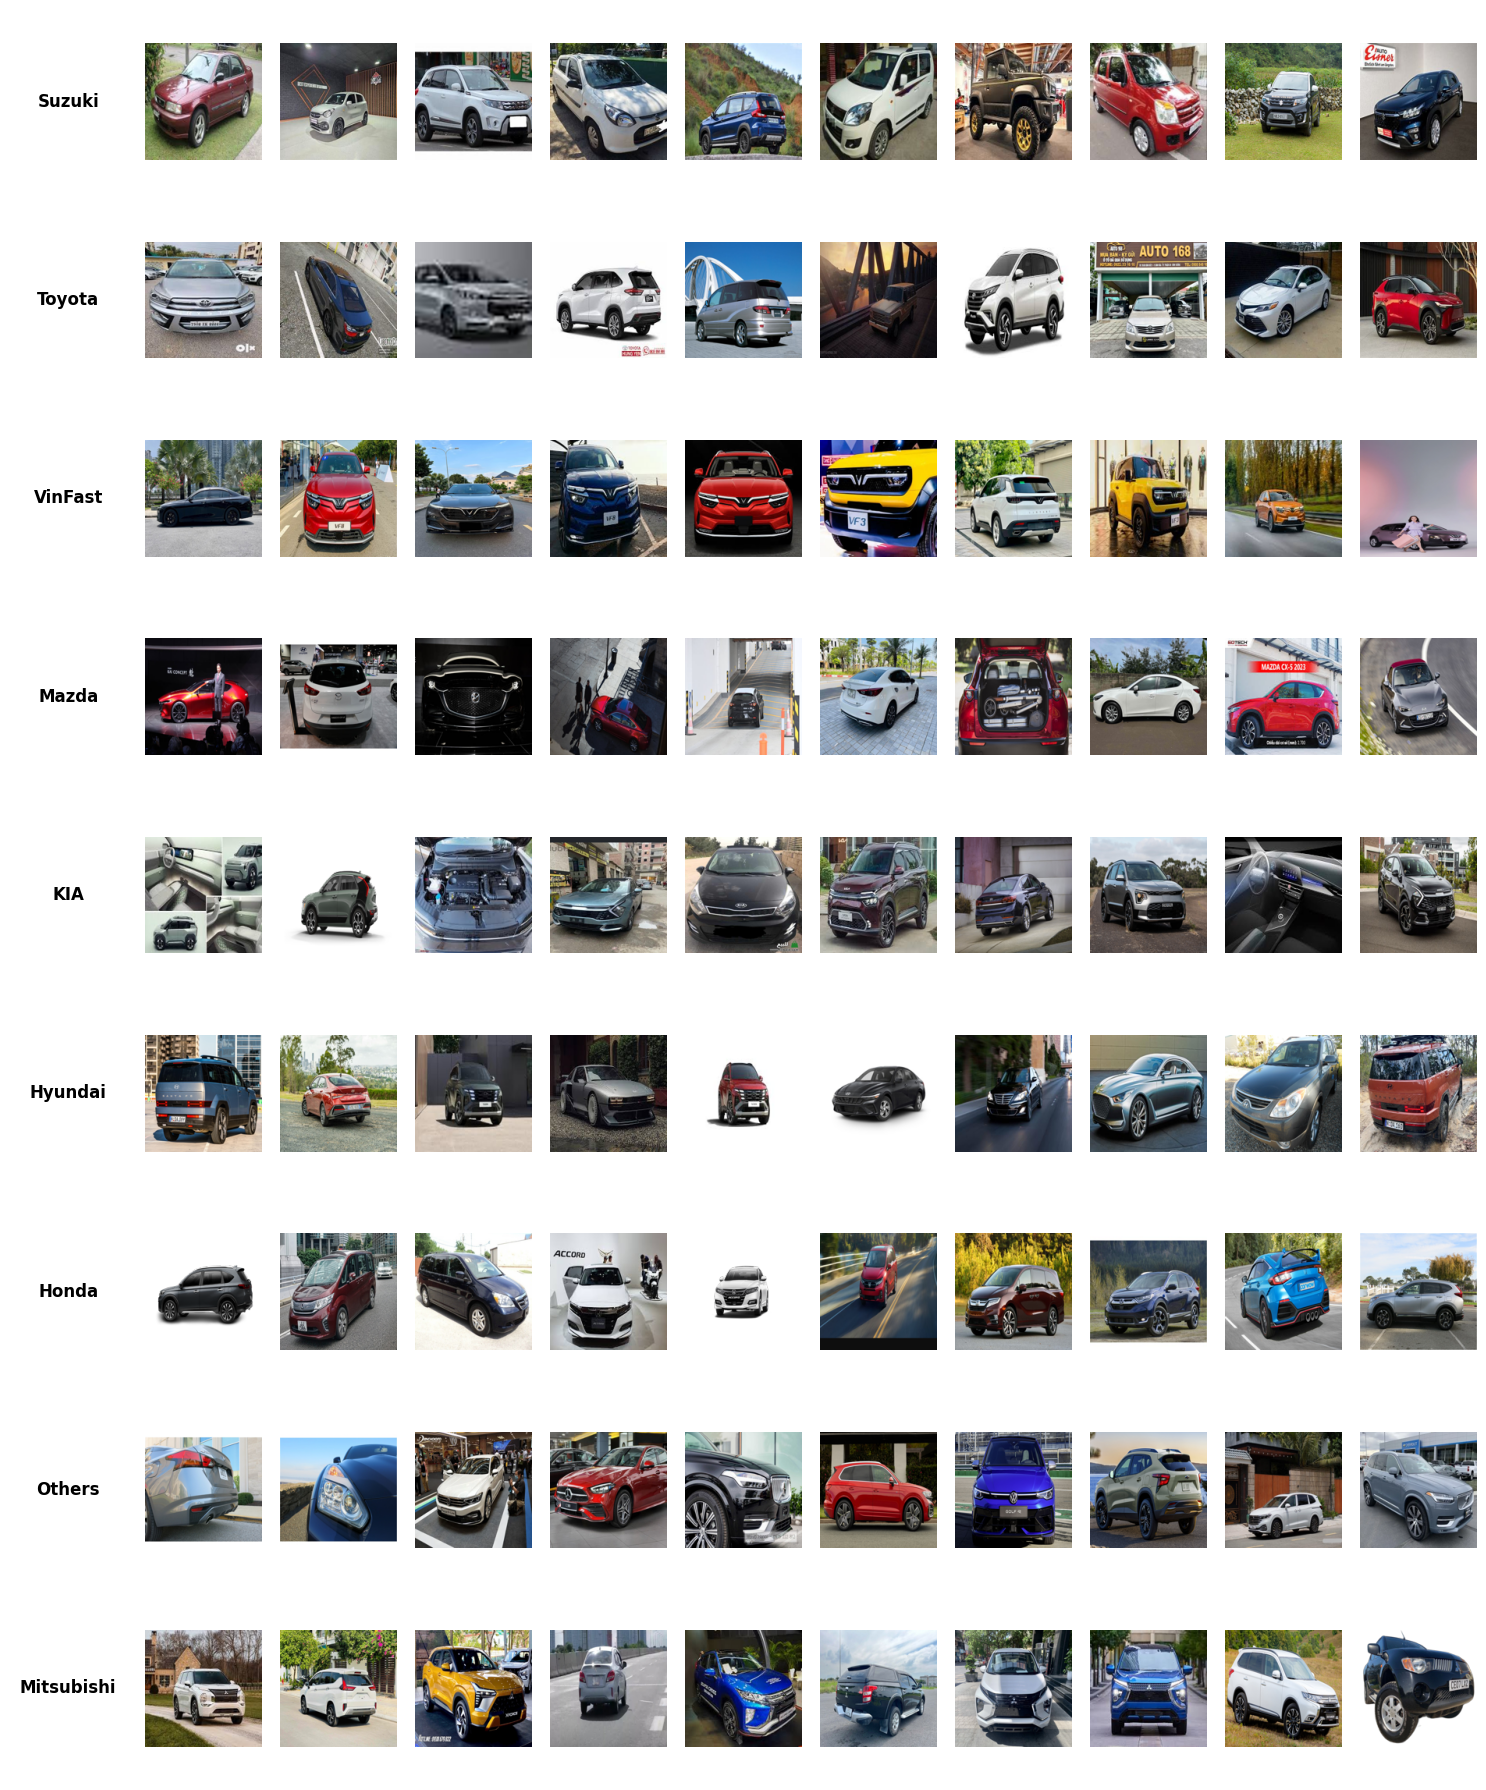

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import random
from PIL import Image

# Từ điển ánh xạ CategoryID sang tên hãng xe
CATEGORY_MAPPING = {
    1: "Honda",
    2: "Hyundai",
    3: "KIA",
    4: "Mazda",
    5: "Mitsubishi",
    6: "Suzuki",
    7: "Toyota",
    8: "VinFast",
    0: "Others"
}

def display_images(csv_file, num_imgs_per_row=10, img_height=150, img_width=150):
    # Đọc file CSV
    df = pd.read_csv(csv_file)

    # Lấy danh sách các CategoryID
    categories = df['CategoryID'].unique()

    # Thiết lập vùng vẽ
    plt.figure(figsize=(num_imgs_per_row * 1.5, len(categories) * 2))

    for i, category in enumerate(categories):
        # Lấy tên hãng xe từ CATEGORY_MAPPING
        category_name = CATEGORY_MAPPING.get(category, "Unknown")

        # Lấy ảnh thuộc category hiện tại
        category_imgs = df[df['CategoryID'] == category]['ImageFullPath'].tolist()

        # Chọn ngẫu nhiên num_imgs_per_row ảnh
        selected_imgs = random.sample(category_imgs, min(len(category_imgs), num_imgs_per_row))

        # Tạo subplot cho tên hãng xe (đặt nó ở đầu hàng)
        ax = plt.subplot(len(categories), num_imgs_per_row + 1, i * (num_imgs_per_row + 1) + 1)
        ax.text(0.5, 0.5, category_name, ha='center', va='center', fontsize=12, fontweight='bold')
        ax.axis("off")  # Không cần hiển thị trục

        # Hiển thị các ảnh trong hàng
        for j, img_path in enumerate(selected_imgs):
            ax = plt.subplot(len(categories), num_imgs_per_row + 1, i * (num_imgs_per_row + 1) + j + 2)

            # Thử mở và hiển thị ảnh
            try:
                img = Image.open(img_path)
                img = img.resize((img_width, img_height))  # Resize ảnh nếu cần thiết
                ax.imshow(img)
                ax.axis("off")
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
                ax.axis("off")

    plt.tight_layout()
    plt.show()

csv_file = r"D:\\VSCode\\CS114\\CarDataset.csv"
display_images(csv_file)
